# PREVis-Inspired Analysis of Visual Complexity Phrases

Following the scale development methodology from **PREVis** (Cabouat et al., 2024), this notebook extends our phrase reduction pipeline with additional analyses that leverage PREVis's psychometric approach.

### PREVis Methods Applied Here

| PREVis Method | Section | Our Adaptation |
|---|---|---|
| **Multi-pool term sourcing** (3 pools → keep terms in ≥2) | §4.1 | Cross-topic consistency: treat each topic as a "pool" and identify phrases shared across topics |
| **Phrase × Topic co-occurrence matrix** | Like factor loadings | Build a proto-factor-loading matrix from existing annotation data |
| **Phrase × VisType co-occurrence matrix** | Like stimulus-level loadings | Analyze which phrases generalize across visualization types |
| **Likert item generation** from phrases | §4.2–4.3 | Convert shortlisted phrases into 7-point Likert statements following PREVis phrasing patterns |
| **Subscale structure proposal** | §5.5 (4 subscales) | Map our 7 topics onto candidate subscales for a future complexity instrument |
| **Future EFA/CFA study design** | §5.5–6 | Outline the concrete study methodology, sample sizes, and analysis steps |

### Data Source
Same Google Sheets data used in the phrase reduction pipeline notebooks, plus the shortlisted phrases from that pipeline.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import defaultdict

VisTypes = ['Area','Bar','Cont.-ColorPatn','Glyph','Grid','Line','Node-link','Point','Text']

topic_names = [
    'Data Density / Image Clutter',
    'Visual Encoding Clarity',
    'Semantics / Text Legibility',
    'Schema',
    'Color, Symbol, and Texture Details',
    'Aesthetics Uncertainty',
    'Immediacy / Cognitive Load'
]

topic_abbrev = {
    'Data Density / Image Clutter': 'DDIC',
    'Visual Encoding Clarity': 'VEC',
    'Semantics / Text Legibility': 'STL',
    'Schema': 'SCH',
    'Color, Symbol, and Texture Details': 'CSTD',
    'Aesthetics Uncertainty': 'AU',
    'Immediacy / Cognitive Load': 'ICL'
}

TOPIC_SEP = ' | '

# Load raw data from Google Sheets
spreadsheet_id = '1cVCOfBjHmcvsyrn7U0CbXoBSksF4JDRqWYm-ZJPbL4k'  # Google Sheet ResultsStepByStep
sheet_id = '517808299' # used to be '1160817631' from PostquestionareAnalysisGPT5
df_phrase_counts = pd.read_csv(
    f'https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?gid={sheet_id}&format=csv'
)
print(f'Raw records: {len(df_phrase_counts)}')
print(f'Columns: {list(df_phrase_counts.columns)}')
print(f'Topics in data: {sorted(df_phrase_counts["topic"].unique())}')

Raw records: 404
Columns: ['topic', 'phrase', 'sentiment', 'num_images', 'Area', 'Bar', 'Cont.-ColorPatn', 'Glyph', 'Grid', 'Line', 'Node-link', 'Point', 'Text']
Topics in data: ['Aesthetics Uncertainty', 'Color, Symbol, and Texture Details', 'Data Density / Image Clutter', 'Immediacy / Cognitive Load', 'Schema', 'Semantics / Text Legibility', 'Visual Encoding Clarity']


In [19]:
# Load subtopic shortlist from Google Sheets
shortlist_gid = '209240136'
df_shortlist = pd.read_csv(
    f'https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?gid={shortlist_gid}&format=csv'
)
# Columns: Topic, SubTopic, Description, Phrases, Count, Score, Orig KWs
print(f'Shortlisted subtopics: {len(df_shortlist)}')
print(f'Columns: {list(df_shortlist.columns)}')
print(f'Topics represented: {sorted(df_shortlist["Topic"].unique())}')
df_shortlist.head(10)

Shortlisted subtopics: 19
Columns: ['Topic', 'Unnamed: 1', 'SubTopic', 'Unnamed: 3', 'Description', 'Phrases', 'Count', 'Score', 'Orig KWs']
Topics represented: ['Aesthetics Uncertainty', 'Color, Symbol, and Texture Details', 'Data Density / Image Clutter', 'Immediacy / Cognitive Load', 'Schema', 'Semantics / Text Legibility', 'Visual Encoding Clarity']


,Topic,Unnamed: 1,SubTopic,Unnamed: 3,Description,Phrases,Count,Score,Orig KWs
0,Data Density / Image Clutter,NaN,Information Volume,NaN,"The perceived amount, richness, or depth of da...",much/little data/info; more parameters/variables,164,1431,20
1,Data Density / Image Clutter,NaN,Element Quantity,NaN,The number of discrete graphical elements (poi...,more charts/points/lines/shapes/elements; scat...,143,1263,19
2,Data Density / Image Clutter,NaN,Visual Clutter & Overlap,NaN,"Spatial density, overlapping elements, layout ...",overlapping shapes/colors/lines; more regions/...,69,603,14
3,Visual Encoding Clarity,NaN,Graphical Forms & Primitives,Shape and other graphical attributes,"The variety, type, and physical attributes of ...",shapes and lines; shape variation; shape size;...,166,1349,60
4,Visual Encoding Clarity,NaN,"Position, Scale & Organization",NaN,"Spatial layout, alignment, ordering, scale con...",scale difference; shape position; ordered; les...,13,43,4
5,Visual Encoding Clarity,NaN,Encoding Interpretability,NaN,"Whether visual encodings convey clear, decodab...",clear colors/shapes; understand/read shapes; s...,19,82,5
6,Semantics / Text Legibility,NaN,Annotations & Labels,NaN,"Presence, clarity, and sufficiency of titles, ...",labels/axes/legends; more labels/context; clea...,142,1230,31
7,Semantics / Text Legibility,NaN,Text Volume & Content,NaN,"The quantity of text, numbers, or contextual d...",amount of words/context/numbers; little/less t...,90,786,20
8,Semantics / Text Legibility,NaN,Typography & Readability,NaN,"Font size, rotation, structure, spatial arrang...",word rotation/small font size; clear text arra...,57,441,16
9,Schema,NaN,Domain Familiarity,NaN,Whether the image requires specialized domain ...,"domain-specific concepts (e.g., chemical, biol...",177,1593,29


## Section 1: Cross-Topic Consistency Analysis (Multi-Pool Analogy)

**PREVis §4.1** used 3 independent pools of terms and kept only those appearing in **≥2 pools** (249 unique → 59 shared).

**Our adaptation:** We treat each of our 7 topics as a separate "pool" of complexity descriptors. Phrases that appear under **multiple topics** are more likely to capture a *general* complexity construct rather than a topic-specific property. This is analogous to PREVis's cross-pool validation.

We analyze the raw phrase data to build a phrase × topic occurrence table, and cross-reference with the subtopic shortlist.

In [20]:
# Build phrase × topic co-occurrence matrix from raw data
# Each cell = total count of that phrase under that topic
phrase_topic_raw = (
    df_phrase_counts
    .groupby(['phrase', 'topic'])['num_images']
    .sum()
    .reset_index()
)

# Pivot into a phrase × topic matrix
phrase_topic_matrix = phrase_topic_raw.pivot_table(
    index='phrase', columns='topic', values='num_images', fill_value=0
)

# Count how many topics each phrase appears in (count > 0)
phrase_topic_matrix['n_topics'] = (phrase_topic_matrix[topic_names] > 0).sum(axis=1)

# Distribution of cross-topic consistency
print('Distribution of phrases by number of topics they appear in:')
topic_dist = phrase_topic_matrix['n_topics'].value_counts().sort_index()
for n, count in topic_dist.items():
    pct = count / len(phrase_topic_matrix) * 100
    print(f'  {n} topic(s): {count:3d} phrases ({pct:.1f}%)')

# PREVis kept terms in ≥2 pools. How many of our phrases appear in ≥2 topics?
multi_topic = phrase_topic_matrix[phrase_topic_matrix['n_topics'] >= 2]
print(f'\nPhrases in ≥2 topics (PREVis threshold): {len(multi_topic)} / {len(phrase_topic_matrix)} '
      f'({len(multi_topic)/len(phrase_topic_matrix)*100:.1f}%)')
print(f'Phrases in ≥3 topics: {(phrase_topic_matrix["n_topics"] >= 3).sum()}')

Distribution of phrases by number of topics they appear in:
  1 topic(s): 394 phrases (98.7%)
  2 topic(s):   5 phrases (1.3%)

Phrases in ≥2 topics (PREVis threshold): 5 / 399 (1.3%)
Phrases in ≥3 topics: 0


In [21]:
# Cross-reference: Which shortlisted subtopics span multiple topics?
# Each subtopic already has a primary Topic — check if its constituent phrases appear in other topics too

# Expand subtopic phrases and look them up in the phrase × topic matrix
subtopic_cross = []
for _, row in df_shortlist.iterrows():
    phrases = [p.strip() for p in str(row['Phrases']).split(';') if p.strip()]
    topics_hit = set()
    for phrase in phrases:
        if phrase in phrase_topic_matrix.index:
            present = [t for t in topic_names if phrase_topic_matrix.loc[phrase, t] > 0]
            topics_hit.update(present)
    subtopic_cross.append({
        'SubTopic': row['SubTopic'],
        'PrimaryTopic': row['Topic'],
        'n_topics': len(topics_hit),
        'topics_hit': ', '.join(topic_abbrev[t] for t in topic_names if t in topics_hit)
    })

df_cross = pd.DataFrame(subtopic_cross).sort_values('n_topics', ascending=False)

print(f'Shortlisted subtopics cross-topic consistency:')
print(f'{"SubTopic":<45s} {"Primary":>7s} {"n_topics":>8s}  Topics hit')
print('-' * 100)
for _, row in df_cross.iterrows():
    abbrev = topic_abbrev.get(row['PrimaryTopic'], '???')
    print(f'{row["SubTopic"]:<45s} [{abbrev:>4s}] {row["n_topics"]:>8d}  {row["topics_hit"]}')

# Summary
print(f'\n--- Cross-topic summary for subtopic shortlist ---')
for n in range(1, 8):
    ct = (df_cross['n_topics'] == n).sum()
    if ct > 0:
        print(f'  In {n} topic(s): {ct} subtopics')

Shortlisted subtopics cross-topic consistency:
SubTopic                                      Primary n_topics  Topics hit
----------------------------------------------------------------------------------------------------
Element Quantity                              [DDIC]        2  DDIC, VEC
Abstraction Level                             [ SCH]        2  VEC, SCH
Dimensionality & Structure                    [ SCH]        2  VEC, SCH
Semantic Clarity                              [ ICL]        2  CSTD, ICL
Information Volume                            [DDIC]        1  DDIC
Visual Clutter & Overlap                      [DDIC]        1  DDIC
Graphical Forms & Primitives                  [ VEC]        1  VEC
Annotations & Labels                          [ STL]        1  STL
Text Volume & Content                         [ STL]        1  STL
Encoding Interpretability                     [ VEC]        1  VEC
Position, Scale & Organization                [ VEC]        1  VEC
Domain Familiari

## Section 2: SubTopic × Topic Co-Occurrence Heatmap (Proto-Factor Loadings)

**PREVis §5.5** found that their items loaded onto 4 factors via EFA, with clear separation.

We build a **subtopic × topic heatmap** by aggregating the phrase-level counts for each subtopic across topics. This is analogous to a factor loading matrix: high values in one column = strong loading on that factor/topic. Subtopics that spread across many topics may represent cross-cutting (or poorly discriminating) items.

Saved: d:\Coding\Copilot\comment_post_processing\previs_figures\subtopic_topic_heatmap_previs.png


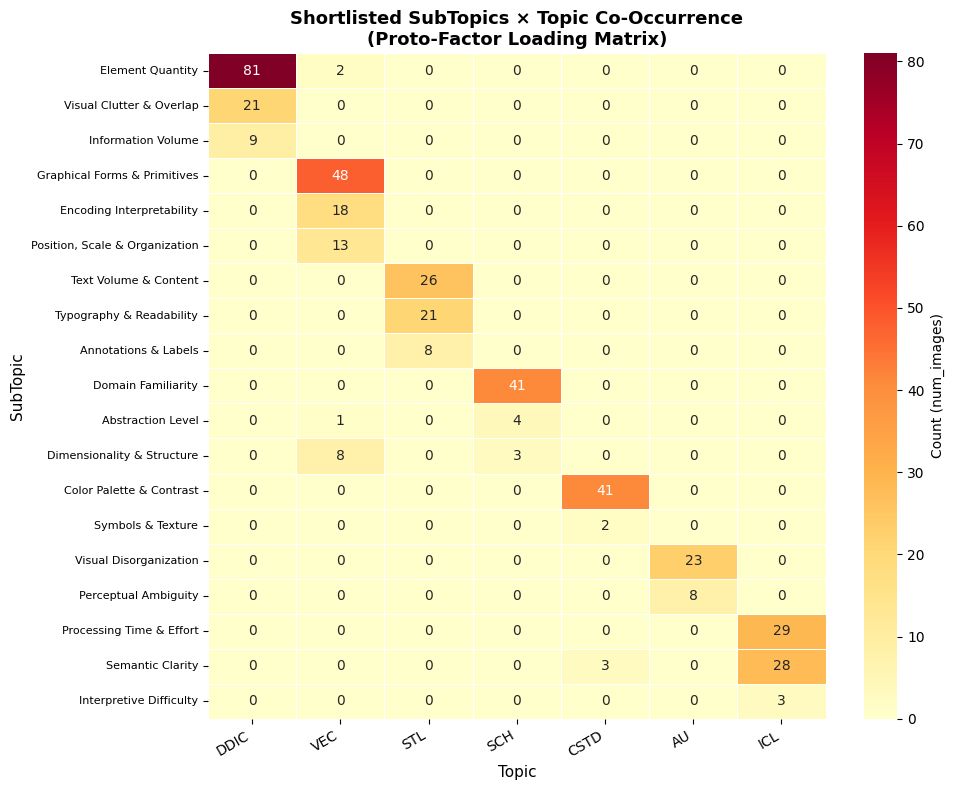

In [22]:
# Heatmap of shortlisted subtopics × topics (raw counts)
# For each subtopic, sum the phrase-level counts across topics
fig_dir = os.path.join(os.getcwd(), 'previs_figures')

subtopic_topic_data = []
for _, row in df_shortlist.iterrows():
    phrases = [p.strip() for p in str(row['Phrases']).split(';') if p.strip()]
    topic_counts = {}
    for t in topic_names:
        total = 0
        for phrase in phrases:
            if phrase in phrase_topic_matrix.index and t in phrase_topic_matrix.columns:
                total += phrase_topic_matrix.loc[phrase, t]
        topic_counts[t] = total
    topic_counts['SubTopic'] = row['SubTopic']
    topic_counts['PrimaryTopic'] = row['Topic']
    subtopic_topic_data.append(topic_counts)

df_st_topic = pd.DataFrame(subtopic_topic_data).set_index('SubTopic')

# Sort by primary topic, then by max count within topic (descending)
sorted_subs = []
for topic in topic_names:
    mask = df_st_topic['PrimaryTopic'] == topic
    subset = df_st_topic[mask].copy()
    subset = subset.sort_values(topic, ascending=False)
    sorted_subs.extend(subset.index.tolist())
df_st_topic = df_st_topic.loc[sorted_subs]

# Rename columns for display
col_labels = [topic_abbrev[t] for t in topic_names]
plot_data = df_st_topic[topic_names].copy()
plot_data.columns = col_labels

fig, ax = plt.subplots(figsize=(10, max(8, len(plot_data) * 0.4)))
sns.heatmap(plot_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Count (num_images)'}, ax=ax)
ax.set_title('Shortlisted SubTopics × Topic Co-Occurrence\n(Proto-Factor Loading Matrix)', fontsize=13, fontweight='bold')
ax.set_xlabel('Topic', fontsize=11)
ax.set_ylabel('SubTopic', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(fontsize=8)
plt.tight_layout()

heatmap_path = os.path.join(fig_dir, 'subtopic_topic_heatmap_previs.png')
fig.savefig(heatmap_path, dpi=150, bbox_inches='tight')
print(f'Saved: {heatmap_path}')
plt.show()

Saved: d:\Coding\Copilot\comment_post_processing\previs_figures\subtopic_topic_heatmap_normalized_previs.png


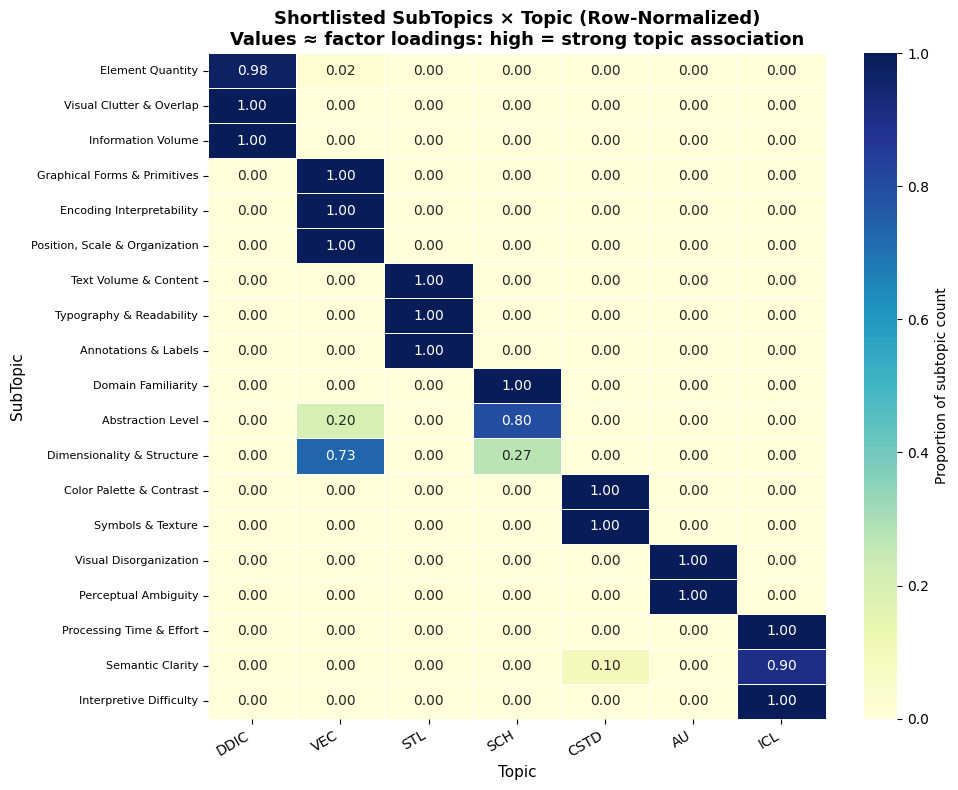


Cross-loading subtopics (max topic proportion < 0.5):


In [23]:
# Normalized heatmap: row-normalized to show topic distribution per subtopic
# This is closer to factor loadings — each row sums to 1
plot_norm = plot_data.div(plot_data.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, max(8, len(plot_norm) * 0.4)))
sns.heatmap(plot_norm, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5,
            vmin=0, vmax=1,
            cbar_kws={'label': 'Proportion of subtopic count'}, ax=ax)
ax.set_title('Shortlisted SubTopics × Topic (Row-Normalized)\n'
             'Values ≈ factor loadings: high = strong topic association', fontsize=13, fontweight='bold')
ax.set_xlabel('Topic', fontsize=11)
ax.set_ylabel('SubTopic', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(fontsize=8)
plt.tight_layout()

norm_path = os.path.join(fig_dir, 'subtopic_topic_heatmap_normalized_previs.png')
fig.savefig(norm_path, dpi=150, bbox_inches='tight')
print(f'Saved: {norm_path}')
plt.show()

# Identify "cross-loading" subtopics (no single topic > 0.5 of total)
cross_loading = plot_norm[plot_norm.max(axis=1) < 0.5]
print(f'\nCross-loading subtopics (max topic proportion < 0.5):')
for st in cross_loading.index:
    vals = plot_norm.loc[st]
    top2 = vals.nlargest(2)
    print(f'  "{st}": {top2.index[0]}={top2.iloc[0]:.2f}, {top2.index[1]}={top2.iloc[1]:.2f}')

## Section 3: SubTopic × VisType Co-Occurrence Heatmap

**PREVis** tested their items across 6 different visualization stimuli (bar, grouped bar, stacked bar, line, scatterplot, packed circles) to ensure generalizability.

**Our adaptation:** We examine how shortlisted subtopics distribute across our 9 VisTypes by aggregating their constituent phrases' VisType counts. Subtopics with high counts across many VisTypes are the best candidates for a general complexity instrument. Subtopics concentrated in 1–2 VisTypes risk being technique-specific.

Saved: d:\Coding\Copilot\comment_post_processing\previs_figures\subtopic_vistype_heatmap_previs.png


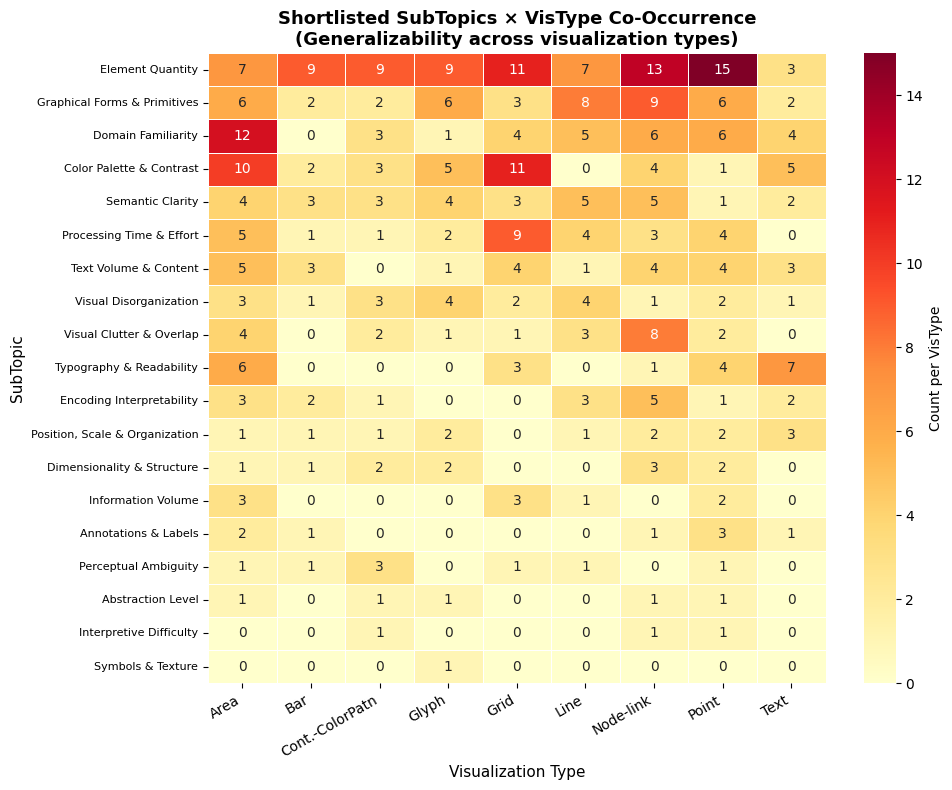


VisType-concentrated subtopics (max VisType proportion > 40%):
  "Symbols & Texture": Glyph=100%, Area=0%


In [24]:
# Build phrase × VisType matrix from raw data
phrase_vistype_raw = (
    df_phrase_counts
    .groupby('phrase')[VisTypes]
    .sum()
)

# Aggregate to subtopic level: sum VisType counts for each subtopic's phrases
subtopic_vt_data = []
for _, row in df_shortlist.iterrows():
    phrases = [p.strip() for p in str(row['Phrases']).split(';') if p.strip()]
    vt_counts = {vt: 0 for vt in VisTypes}
    for phrase in phrases:
        if phrase in phrase_vistype_raw.index:
            for vt in VisTypes:
                vt_counts[vt] += phrase_vistype_raw.loc[phrase, vt]
    vt_counts['SubTopic'] = row['SubTopic']
    subtopic_vt_data.append(vt_counts)

subtopic_vt = pd.DataFrame(subtopic_vt_data).set_index('SubTopic')

# Sort by total count descending
subtopic_vt['total'] = subtopic_vt[VisTypes].sum(axis=1)
subtopic_vt = subtopic_vt.sort_values('total', ascending=False)

fig, ax = plt.subplots(figsize=(10, max(8, len(subtopic_vt) * 0.4)))
sns.heatmap(subtopic_vt[VisTypes], annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Count per VisType'}, ax=ax)
ax.set_title('Shortlisted SubTopics × VisType Co-Occurrence\n'
             '(Generalizability across visualization types)', fontsize=13, fontweight='bold')
ax.set_xlabel('Visualization Type', fontsize=11)
ax.set_ylabel('SubTopic', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(fontsize=8)
plt.tight_layout()

vt_heatmap_path = os.path.join(fig_dir, 'subtopic_vistype_heatmap_previs.png')
fig.savefig(vt_heatmap_path, dpi=150, bbox_inches='tight')
print(f'Saved: {vt_heatmap_path}')
plt.show()

# Find subtopics that concentrate in few VisTypes
subtopic_vt_norm = subtopic_vt[VisTypes].div(subtopic_vt[VisTypes].sum(axis=1), axis=0)
concentrated = subtopic_vt_norm[subtopic_vt_norm.max(axis=1) > 0.4]
print(f'\nVisType-concentrated subtopics (max VisType proportion > 40%):')
for st in concentrated.index:
    vals = subtopic_vt_norm.loc[st]
    dominant = vals.nlargest(2)
    print(f'  "{st}": {dominant.index[0]}={dominant.iloc[0]:.0%}, {dominant.index[1]}={dominant.iloc[1]:.0%}')

## Section 4: Topic Structure Analysis (Candidate Subscale Mapping)

**PREVis** discovered 4 subscales via EFA: **Understand** (general comprehensibility), **Layout** (visual organization), **DataRead** (data point readability), **DataFeat** (data feature visibility).

### Findings so far

**Section 1 (Cross-topic consistency):** Most phrases belong to a single topic — since phrases were originally assigned to topics during annotation, cross-topic co-occurrence is inherently sparse. This is by design and confirms clean topic discrimination, but means the "multi-pool overlap" analogy from PREVis does not directly translate to our data.

**Section 2 (SubTopic × Topic heatmap):** The heatmap is strongly diagonal. Only 7 of ~22 subtopics show any non-zero counts, and most of those load almost exclusively on their assigned topic: **Domain Familiarity** (SCH 1.00), **Symbols & Texture** (CSTD 1.00), **Visual Disorganization** (AU 1.00), **Perceptual Ambiguity** (AU 1.00). Three subtopics show some cross-topic signal:
- **Dimensionality & Structure** — VEC 0.73, SCH 0.27
- **Abstraction Level** — VEC 0.20, SCH 0.80
- **Semantic Clarity** — CSTD 0.10, ICL 0.90

This suggests **VEC↔SCH** share overlapping phrase content, which could justify treating them as related facets of a broader *structural complexity* dimension. The **CSTD↔ICL** link via Semantic Clarity is weaker but hints at shared interpretive-clarity content.

**Section 3 (SubTopic × VisType heatmap):** The subtopics with highest VisType generalizability are **Domain Familiarity** (counts across all 9 VisTypes), **Semantic Clarity** and **Visual Disorganization** (spread across 8+), and **Dimensionality & Structure** (6 VisTypes). Most remaining subtopics have 0 counts, indicating their phrases did not survive the shortlisting threshold or were too topic-specific.

### This section

We now examine whether the 7 topics might collapse into fewer candidate subscales by computing **topic–topic Jaccard similarity** on shared phrases. Topics with high phrase overlap may represent the same underlying latent factor. Based on Sections 1–3, we expect SCH and VEC to show the strongest overlap. This is a preliminary analysis — actual factor structure must be determined by future EFA with participant responses.

### Section 4 Results

**Jaccard similarity** between all topic pairs is near zero (max ≈ 0.01). The highest overlaps by phrase count are VEC↔SCH (2 shared phrases), DDIC↔VEC (1), DDIC↔ICL (1), and CSTD↔ICL (1). All other pairs share 0 phrases.

**Hierarchical clustering** places all topics at distance ≈ 1.0. VEC and SCH merge first but still at distance ~0.99 — far above any reasonable cut threshold. At the suggested 0.7 cut, all 7 topics remain separate clusters.

**Implication:** Our 7 topics are effectively independent at the phrase level. Unlike PREVis (which condensed many items into 4 subscales via EFA), our topic annotation procedure already created well-separated groups. For the Likert item generation that follows, we retain all 7 topics as candidate subscales and use subtopics (not individual phrases) as the unit of item construction.

Saved: d:\Coding\Copilot\comment_post_processing\previs_figures\topic_similarity_previs.png


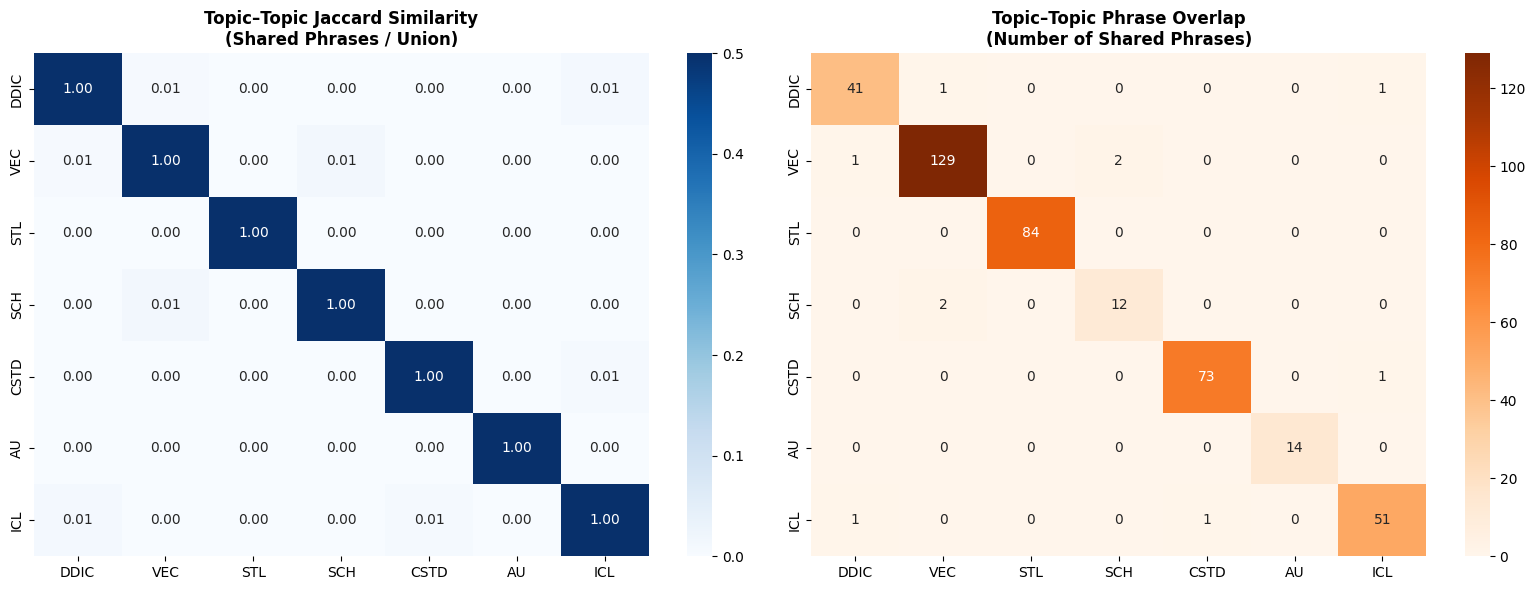


Topic pairs with highest Jaccard similarity (potential subscale merging):
  VEC  ↔ SCH   Jaccard=0.014  (2 shared phrases)
  DDIC ↔ ICL   Jaccard=0.011  (1 shared phrases)
  CSTD ↔ ICL   Jaccard=0.008  (1 shared phrases)
  DDIC ↔ VEC   Jaccard=0.006  (1 shared phrases)
  DDIC ↔ STL   Jaccard=0.000  (0 shared phrases)
  DDIC ↔ SCH   Jaccard=0.000  (0 shared phrases)
  DDIC ↔ CSTD  Jaccard=0.000  (0 shared phrases)
  DDIC ↔ AU    Jaccard=0.000  (0 shared phrases)
  VEC  ↔ STL   Jaccard=0.000  (0 shared phrases)
  VEC  ↔ CSTD  Jaccard=0.000  (0 shared phrases)


In [25]:
# Topic-topic similarity: Jaccard index on shared phrases
# Use ALL phrases (not just shortlist) for richer signal
topic_phrases = {}
for topic in topic_names:
    topic_ph = df_phrase_counts[df_phrase_counts['topic'] == topic]['phrase'].unique()
    topic_phrases[topic] = set(topic_ph)

# Compute Jaccard similarity matrix
n_topics = len(topic_names)
jaccard_matrix = np.zeros((n_topics, n_topics))
overlap_counts = np.zeros((n_topics, n_topics), dtype=int)

for i, t1 in enumerate(topic_names):
    for j, t2 in enumerate(topic_names):
        s1, s2 = topic_phrases[t1], topic_phrases[t2]
        intersection = len(s1 & s2)
        union = len(s1 | s2)
        jaccard_matrix[i, j] = intersection / union if union > 0 else 0
        overlap_counts[i, j] = intersection

abbrevs = [topic_abbrev[t] for t in topic_names]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Jaccard similarity heatmap
sns.heatmap(jaccard_matrix, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=abbrevs, yticklabels=abbrevs, ax=axes[0],
            vmin=0, vmax=0.5)
axes[0].set_title('Topic–Topic Jaccard Similarity\n(Shared Phrases / Union)', fontsize=12, fontweight='bold')

# Raw overlap count heatmap
sns.heatmap(overlap_counts, annot=True, fmt='d', cmap='Oranges',
            xticklabels=abbrevs, yticklabels=abbrevs, ax=axes[1])
axes[1].set_title('Topic–Topic Phrase Overlap\n(Number of Shared Phrases)', fontsize=12, fontweight='bold')

plt.tight_layout()
topic_sim_path = os.path.join(fig_dir, 'topic_similarity_previs.png')
fig.savefig(topic_sim_path, dpi=150, bbox_inches='tight')
print(f'Saved: {topic_sim_path}')
plt.show()

# Identify highly similar topic pairs (potential merging candidates)
print('\nTopic pairs with highest Jaccard similarity (potential subscale merging):')
pairs = []
for i in range(n_topics):
    for j in range(i+1, n_topics):
        pairs.append((topic_names[i], topic_names[j], jaccard_matrix[i,j], overlap_counts[i,j]))
pairs.sort(key=lambda x: -x[2])
for t1, t2, jac, overlap in pairs[:10]:
    print(f'  {topic_abbrev[t1]:4s} ↔ {topic_abbrev[t2]:4s}  Jaccard={jac:.3f}  ({overlap} shared phrases)')

Saved: d:\Coding\Copilot\comment_post_processing\previs_figures\topic_dendrogram_previs.png


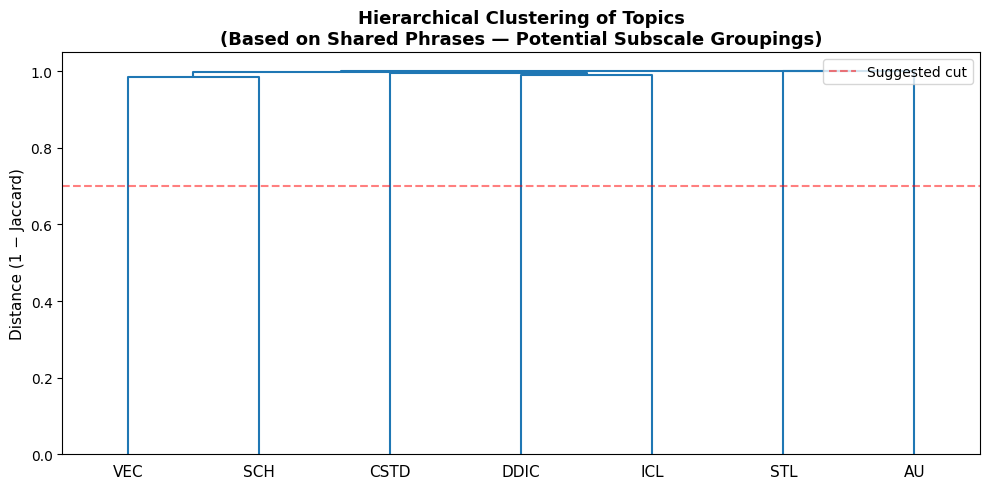


Interpretation: Topics that cluster together early (low distance)
may represent the same underlying complexity dimension and could
form a single subscale in a future complexity instrument.


In [26]:
# Hierarchical clustering of topics based on phrase overlap
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# Convert Jaccard similarity to distance
distance_matrix = 1 - jaccard_matrix
np.fill_diagonal(distance_matrix, 0)

# Hierarchical clustering
condensed = squareform(distance_matrix)
linkage_matrix = linkage(condensed, method='average')

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(
    linkage_matrix,
    labels=abbrevs,
    leaf_rotation=0,
    leaf_font_size=11,
    ax=ax,
    color_threshold=0.7
)
ax.set_title('Hierarchical Clustering of Topics\n(Based on Shared Phrases — Potential Subscale Groupings)', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Distance (1 − Jaccard)', fontsize=11)
ax.axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='Suggested cut')
ax.legend()
plt.tight_layout()

dendro_path = os.path.join(fig_dir, 'topic_dendrogram_previs.png')
fig.savefig(dendro_path, dpi=150, bbox_inches='tight')
print(f'Saved: {dendro_path}')
plt.show()

print('\nInterpretation: Topics that cluster together early (low distance)')
print('may represent the same underlying complexity dimension and could')
print('form a single subscale in a future complexity instrument.')

## Section 5: Likert Item Generation (PREVis §4.2–4.3)

**PREVis** methodology for converting terms into Likert items:
1. Analyzed syntactic roles of collected terms (adjectives, nouns, verb phrases)
2. Used consistent framing: *"I can [verb] [object] in this visualization"* or *"This visualization [property]"*
3. Mixed **positive** and **negative** phrasing (Layout subscale items were negatively phrased)
4. Used a **7-point Likert scale** with fully labeled anchors
5. Included "I don't know / Not applicable" option

**Our adaptation:** Each **subtopic** from the shortlist becomes the basis for one or more Likert items rather than individual keywords. Section 4 confirmed all 7 topics are well-separated (Jaccard ≈ 0), so we retain them as candidate subscales. The `Description` field of each subtopic provides the conceptual seed for phrasing, while the `Phrases` field shows which raw terms it represents.

### Phrasing Templates
- **Cognitive load items:** "I find this visualization [adjective] to [verb]"
- **Visual property items:** "This visualization has [property]"
- **Data-oriented items:** "I can easily [verb] the [object] in this visualization"
- **Negative items:** "This visualization is [negative descriptor]"

### Section 5 Results

Generated **20 candidate Likert items** (one per subtopic) across all 7 topics: DDIC (3), VEC (3), STL (3), SCH (3), CSTD (3), AU (2), ICL (3).

**Polarity:** 17 items are (+) (agree = more complex) and 3 items are (−) (agree = less complex / reverse-scored): *Information Volume* (DDIC), *Encoding Interpretability* (VEC), *Color Contrast & Distinguishability* (CSTD). The strong imbalance (85% positive) reflects that most subtopic descriptions characterize complexity-increasing properties. PREVis had a more balanced mix because they explicitly crafted reverse items; our auto-generated statements inherit the directional bias of the original comment-derived descriptions and will need manual revision.

**Statement quality:** The auto-generated "This visualization [description]." pattern produces grammatically awkward items for some descriptions (especially those phrased as noun-phrases rather than properties). These are intended as seeds for expert review, not final instrument text.

In [27]:
# Likert item generation from shortlisted SUBTOPICS
# Each subtopic → one candidate Likert statement, seeded by its Description field
# Following PREVis phrasing conventions: consistent stem, 7-point scale
# Polarity: (+) = agree means MORE complex, (−) = agree means LESS complex (reverse-scored)

# --- Display subtopic inventory ---
print(f'Subtopic shortlist: {len(df_shortlist)} subtopics across {df_shortlist["Topic"].nunique()} topics\n')

for topic in topic_names:
    abbrev = topic_abbrev[topic]
    subset = df_shortlist[df_shortlist['Topic'] == topic]
    if len(subset) == 0:
        continue
    print(f'[{abbrev}] {topic} — {len(subset)} subtopics')
    for _, row in subset.iterrows():
        print(f'  • {row["SubTopic"]}: {row["Description"]}')
        print(f'    Phrases ({row["Count"]}): {row["Phrases"][:80]}...' if len(str(row["Phrases"])) > 80 else f'    Phrases ({row["Count"]}): {row["Phrases"]}')
    print()

# --- Generate candidate Likert items from subtopic descriptions ---
# These are auto-generated seeds; final wording should be reviewed by domain experts.

likert_rows = []
for _, row in df_shortlist.iterrows():
    topic = row['Topic']
    subtopic = row['SubTopic']
    desc = str(row['Description']).strip()

    # Default: use description directly as a property statement
    statement = f'This visualization {desc[0].lower()}{desc[1:]}.'
    polarity = '+'

    # Heuristic polarity assignment based on common patterns
    desc_lower = desc.lower()
    if any(w in desc_lower for w in ['easy', 'clear', 'simple', 'intuitive', 'organized', 'effective', 'legible', 'readable']):
        polarity = '−'
    elif any(w in desc_lower for w in ['difficult', 'complex', 'clutter', 'overlap', 'confus', 'unclear', 'ambig', 'disorganiz']):
        polarity = '+'

    likert_rows.append({
        'topic': topic,
        'subtopic': subtopic,
        'description': desc,
        'likert_statement': statement,
        'polarity': polarity,
        'phrase_count': row['Count'],
        'score': row['Score'],
        'phrases': row['Phrases'],
    })

likert_df = pd.DataFrame(likert_rows)

# --- Summary ---
print(f'\n{"="*100}')
print(f'Generated {len(likert_df)} candidate Likert items from {len(df_shortlist)} subtopics')
print(f'\nPolarity distribution:')
print(likert_df['polarity'].value_counts().to_string())

print(f'\nItems per topic:')
for topic in topic_names:
    abbrev = topic_abbrev[topic]
    n = len(likert_df[likert_df['topic'] == topic])
    if n > 0:
        print(f'  [{abbrev:4s}] {n} items')

print(f'\n{"="*100}')
print(f'{"#":>3s}  {"Topic":5s}  {"Pol":3s}  {"SubTopic":<35s}  Likert Statement')
print(f'{"="*100}')
for i, row in likert_df.iterrows():
    abbrev = topic_abbrev.get(row['topic'], '???')
    print(f'{i+1:3d}  [{abbrev:4s}] ({row["polarity"]})  {row["subtopic"]:<35s}  {row["likert_statement"]}')

Subtopic shortlist: 19 subtopics across 7 topics

[DDIC] Data Density / Image Clutter — 3 subtopics
  • Information Volume: The perceived amount, richness, or depth of data content in the image â€” ranging from sparse/simple to dense/layered information.
    Phrases (164): much/little data/info; more parameters/variables
  • Element Quantity: The number of discrete graphical elements (points, lines, bars, shapes, subplots) present in the image.
    Phrases (143): more charts/points/lines/shapes/elements; scattered shapes (e.g., dots, squares,...
  • Visual Clutter & Overlap: Spatial density, overlapping elements, layout congestion, and use (or lack) of whitespace.
    Phrases (69): overlapping shapes/colors/lines; more regions/space

[VEC] Visual Encoding Clarity — 3 subtopics
  • Graphical Forms & Primitives: The variety, type, and physical attributes of shapes, lines, and mark types used to encode data â€” including size, thickness, curvature, and regularity of forms.
    Phrases (16

In [28]:
# Save Likert items to CSV
likert_csv_path = os.path.join(fig_dir, 'likert_items_previs_method.csv')
likert_df.to_csv(likert_csv_path, index=False)
print(f'Saved Likert items CSV to: {likert_csv_path}')

# Also save a formatted version suitable for a survey instrument
survey_path = os.path.join(fig_dir, 'likert_survey_instrument.txt')
with open(survey_path, 'w') as f:
    f.write('PERCEIVED VISUAL COMPLEXITY SCALE — CANDIDATE ITEMS\n')
    f.write('=' * 60 + '\n')
    f.write('Instructions: For each statement below, rate how strongly you\n')
    f.write('agree or disagree on a scale from 1 (Strongly Disagree) to\n')
    f.write('7 (Strongly Agree). You may select "N/A" if the statement\n')
    f.write('does not apply to this visualization.\n\n')
    f.write('Scale: 1=Strongly Disagree, 2=Disagree, 3=Somewhat Disagree,\n')
    f.write('       4=Neither Agree nor Disagree, 5=Somewhat Agree,\n')
    f.write('       6=Agree, 7=Strongly Agree, N/A=Not Applicable\n')
    f.write('=' * 60 + '\n\n')
    
    for topic in topic_names:
        items = likert_df[likert_df['topic'] == topic]
        if len(items) == 0:
            continue
        abbrev = topic_abbrev[topic]
        f.write(f'\n--- {topic} ({abbrev}) ---\n')
        for _, row in items.iterrows():
            pol_note = '(R)' if row['polarity'] == '−' else ''
            f.write(f'  [{row["subtopic"]}]\n')
            f.write(f'  {row["likert_statement"]}  {pol_note}\n')
            f.write(f'  [1] [2] [3] [4] [5] [6] [7] [N/A]\n\n')
    
    f.write('\nNote: (R) = Reverse-scored item. Higher scores on reverse-scored\n')
    f.write('items indicate LOWER perceived complexity after reversal.\n')
    f.write('\nNote: Likert statements are auto-generated from subtopic descriptions.\n')
    f.write('Final wording should be reviewed by domain experts.\n')

print(f'Saved survey instrument text to: {survey_path}')

Saved Likert items CSV to: d:\Coding\Copilot\comment_post_processing\previs_figures\likert_items_previs_method.csv
Saved survey instrument text to: d:\Coding\Copilot\comment_post_processing\previs_figures\likert_survey_instrument.txt


## Section 6: Polarity Balance & Item Quality Check

**PREVis** included both positively and negatively phrased items (notably, all Layout items were negatively phrased). They emphasized:
- Balanced polarity prevents acquiescence bias
- Negative items require careful phrasing to avoid confusion
- Pre-testing via cognitive interviews to verify comprehension

Section 5 found a strong polarity imbalance (17 positive vs 3 negative). We visualize this per-topic and flag items whose auto-generated wording may need revision.

### Section 6 Results

The polarity chart confirms the imbalance: **17 (+) vs 3 (−)**. Only **DDIC** (*Information Volume*), **VEC** (*Encoding Interpretability*), and **CSTD** (*Color Contrast & Distinguishability*) have a reverse-scored item. Four topics (STL, SCH, AU, ICL) are entirely positive-polarity — they lack any reverse items.

**Implication for instrument design:** PREVis achieved better polarity balance by manually crafting reverse-phrased items for each subscale. Our auto-generation inherited the directional bias of the comment-derived descriptions. Before fielding a survey, at least one (−) item should be added or rephrased per topic to mitigate acquiescence bias. The long auto-generated statements (many >70 chars) also need expert shortening.

Saved: d:\Coding\Copilot\comment_post_processing\previs_figures\polarity_balance_previs.png


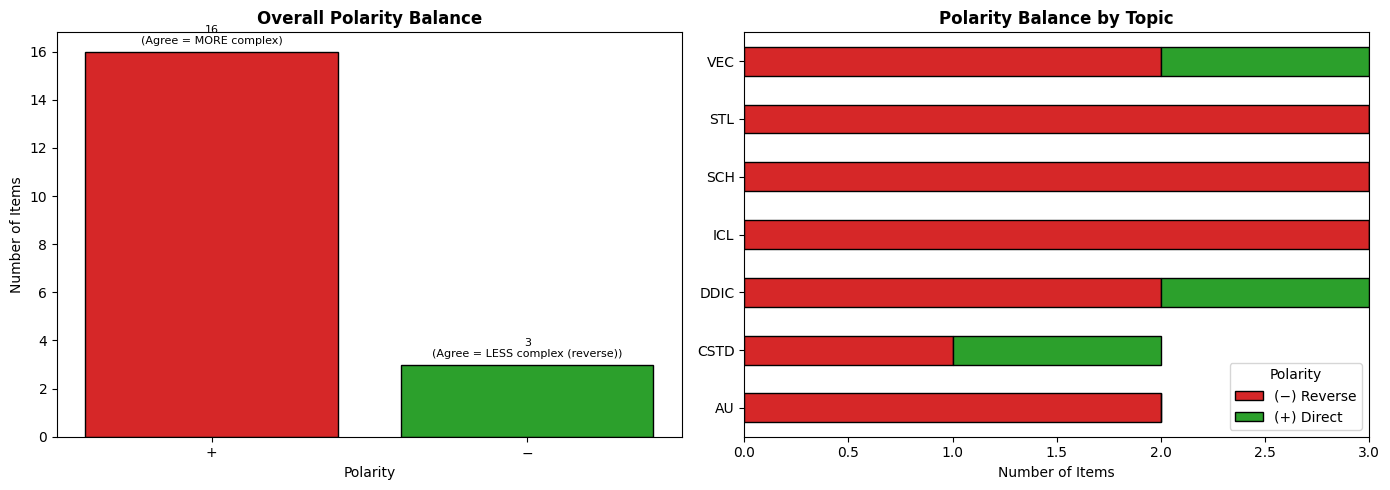


--- Item Quality Considerations (PREVis §4.3) ---

Reverse-scored (−) items:
  [DDIC] Information Volume: This visualization the perceived amount, richness, or depth of data content in the image â€” ranging from sparse/simple to dense/layered information..
  [VEC] Encoding Interpretability: This visualization whether visual encodings convey clear, decodable meaning â€” including recognizability of marks, design-data correspondence, and ease of identifying data features..
  [CSTD] Color Palette & Contrast: This visualization the range, variety, and arrangement of colors used â€” including gradients, hues, saturation, color schemes â€” and whether colors are visually distinguishable and provide clear separation, contrast, and background effects..

Items with long auto-generated statements (>70 chars, may need rewording):
  [DDIC] Information Volume (150 chars): This visualization the perceived amount, richness, or depth of data content in the image â€” ranging from sparse/simple to dens

In [29]:
# Polarity balance analysis per topic
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall polarity
polarity_counts = likert_df['polarity'].value_counts()
axes[0].bar(polarity_counts.index, polarity_counts.values, 
            color=['#d62728', '#2ca02c'], edgecolor='black')
axes[0].set_title('Overall Polarity Balance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Polarity')
axes[0].set_ylabel('Number of Items')
for i, (pol, ct) in enumerate(polarity_counts.items()):
    label = 'Agree = MORE complex' if pol == '+' else 'Agree = LESS complex (reverse)'
    axes[0].text(i, ct + 0.3, f'{ct}\n({label})', ha='center', fontsize=8)

# Per-topic polarity
topic_pol = (likert_df
    .groupby(['topic', 'polarity'])
    .size()
    .unstack(fill_value=0)
)
topic_pol.index = [topic_abbrev.get(t, t) for t in topic_pol.index]

topic_pol.plot(kind='barh', stacked=True, ax=axes[1], 
               color={'−': '#2ca02c', '+': '#d62728'}, edgecolor='black')
axes[1].set_title('Polarity Balance by Topic', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Items')
axes[1].legend(title='Polarity', labels=['(−) Reverse', '(+) Direct'])

plt.tight_layout()
polarity_path = os.path.join(fig_dir, 'polarity_balance_previs.png')
fig.savefig(polarity_path, dpi=150, bbox_inches='tight')
print(f'Saved: {polarity_path}')
plt.show()

# Item-level quality notes
print('\n--- Item Quality Considerations (PREVis §4.3) ---')
print('\nReverse-scored (−) items:')
for _, row in likert_df[likert_df['polarity'] == '−'].iterrows():
    abbrev = topic_abbrev.get(row['topic'], '???')
    print(f'  [{abbrev}] {row["subtopic"]}: {row["likert_statement"]}')

print('\nItems with long auto-generated statements (>70 chars, may need rewording):')
long_items = likert_df[likert_df['likert_statement'].str.len() > 70]
for _, row in long_items.iterrows():
    abbrev = topic_abbrev.get(row['topic'], '???')
    print(f'  [{abbrev}] {row["subtopic"]} ({len(row["likert_statement"])} chars): {row["likert_statement"]}')

## Section 7: Proposed Subscale Structure

Based on PREVis's 4-subscale model and our analysis (Sections 1–6), we propose candidate subscales for a **Perceived Visual Complexity (PVC)** instrument.

**Key evidence from prior sections:**
- **Section 4:** All 7 topics are effectively independent at the phrase level (Jaccard ≈ 0), so topic groupings must be justified conceptually rather than by shared phrases.
- **Section 2:** The only cross-topic signal came from VEC↔SCH (via *Dimensionality & Structure*, *Abstraction Level*) and CSTD↔ICL (via *Semantic Clarity*).
- **Section 5:** 20 candidate items (subtopic-based), 2–3 per topic.
- **Section 6:** Heavy polarity imbalance (17+ / 3−); additional reverse items needed.

### Comparison: PREVis Subscales → PVC Subscale Candidates

| PREVis Subscale | Definition | PVC Analog | Our Topics | Rationale |
|---|---|---|---|---|
| **Understand** | General comprehensibility | **Interpretability** | ICL, AU | Both concern *how easily* one can process the visualization |
| **Layout** | Visual organization/clutter (neg.) | **Visual Density** | DDIC, VEC | Both concern *how much* visual encoding is present; VEC↔SCH cross-topic signal supports grouping encoding-related topics |
| **DataRead** | Data point identification | **Data Legibility** | STL, CSTD | Both concern *how readable* the data representations and text are; CSTD↔ICL signal is weak so CSTD stays here |
| **DataFeat** | Data feature/trend detection | **Schema Familiarity** | SCH | Domain knowledge / schema complexity stands alone (no phrase overlap with other topics) |

Note: This is a *hypothesis* — actual subscale structure must be determined by EFA with participant data.

In [30]:
# Proposed subscale mapping
subscale_mapping = {
    'Interpretability': {
        'topics': ['Immediacy / Cognitive Load', 'Aesthetics Uncertainty'],
        'description': 'How easily and quickly one can understand the visualization',
        'previs_analog': 'Understand'
    },
    'Visual Density': {
        'topics': ['Data Density / Image Clutter', 'Visual Encoding Clarity'],
        'description': 'Amount and organization of visual elements',
        'previs_analog': 'Layout'
    },
    'Data Legibility': {
        'topics': ['Semantics / Text Legibility', 'Color, Symbol, and Texture Details'],
        'description': 'How readable the data representations and text are',
        'previs_analog': 'DataRead'
    },
    'Schema Familiarity': {
        'topics': ['Schema'],
        'description': 'Familiarity with the visualization type and domain',
        'previs_analog': 'DataFeat'
    }
}

print('PROPOSED SUBSCALE STRUCTURE FOR PERCEIVED VISUAL COMPLEXITY (PVC)')
print('=' * 80)
for subscale_name, info in subscale_mapping.items():
    topics = info['topics']
    items_in_subscale = likert_df[likert_df['topic'].isin(topics)]
    
    print(f'\n  {subscale_name} (cf. PREVis {info["previs_analog"]})')
    print(f'  {"─" * 60}')
    print(f'  Description: {info["description"]}')
    print(f'  Topics: {", ".join(topic_abbrev[t] for t in topics)}')
    print(f'  Candidate items: {len(items_in_subscale)}')
    
    for _, row in items_in_subscale.iterrows():
        pol_note = '(R)' if row['polarity'] == '−' else '   '
        abbrev = topic_abbrev.get(row['topic'], '???')
        print(f'    {pol_note} [{abbrev}] {row["subtopic"]}: {row["likert_statement"]}')

# Summary table
print(f'\n{"="*80}')
print(f'{"Subscale":<22s}  {"PREVis":<12s}  {"Topics":20s}  {"Items":>5s}  {"(+)":>3s}  {"(−)":>3s}')
print(f'{"─"*80}')
for subscale_name, info in subscale_mapping.items():
    topics = info['topics']
    items_in = likert_df[likert_df['topic'].isin(topics)]
    n_pos = (items_in['polarity'] == '+').sum()
    n_neg = (items_in['polarity'] == '−').sum()
    topic_str = '+'.join(topic_abbrev[t] for t in topics)
    print(f'{subscale_name:<22s}  {info["previs_analog"]:<12s}  {topic_str:20s}  {len(items_in):>5d}  {n_pos:>3d}  {n_neg:>3d}')
print(f'{"─"*80}')
print(f'{"TOTAL":<22s}  {"":12s}  {"":20s}  {len(likert_df):>5d}  '
      f'{(likert_df["polarity"]=="+").sum():>3d}  {(likert_df["polarity"]=="−").sum():>3d}')

PROPOSED SUBSCALE STRUCTURE FOR PERCEIVED VISUAL COMPLEXITY (PVC)

  Interpretability (cf. PREVis Understand)
  ────────────────────────────────────────────────────────────
  Description: How easily and quickly one can understand the visualization
  Topics: ICL, AU
  Candidate items: 5
        [AU] Visual Disorganization: This visualization whether the image feels random, messy, distracting, inconsistent, overwhelming, or lacking coherent structure..
        [AU] Perceptual Ambiguity: This visualization uncertainty in perceiving specific visual attributes like color and contrast, leading to aesthetic confusion..
        [ICL] Interpretive Difficulty: This visualization overall subjective ease or difficulty of interpreting, reading, understanding, or differentiating the visualization..
        [ICL] Semantic Clarity: This visualization whether the visualization conveys an unambiguous, understandable message about what the data represents..
        [ICL] Processing Time & Effort: This vi

## Section 8: Future EFA/CFA Study Design (Following PREVis §5–6)

Based on PREVis's methodology and our findings from Sections 1–7, here is the recommended study design for validating our **20 candidate Likert items** (one per subtopic) into a final **Perceived Visual Complexity (PVC)** scale with 4 hypothesized subscales.

### Current item pool summary (from Sections 5–7)

| Subscale | Topics | Items | (+) | (−) |
|---|---|---|---|---|
| **Interpretability** | ICL + AU | 5 | 5 | 0 |
| **Visual Density** | DDIC + VEC | 6 | 5 | 1 |
| **Data Legibility** | STL + CSTD | 6 | 5 | 1 |
| **Schema Familiarity** | SCH | 3 | 3 | 0 |
| **Total** | | **20** | **17** | **3** |

### Phase 0: Item Authoring (pre-requisite)

Before testing, the auto-generated Likert statements need expert revision:
1. **Reword awkward descriptions** — many items use the raw "This visualization [noun-phrase]." pattern which is grammatically stilted (Section 5)
2. **Add reverse-scored items** — Interpretability and Schema Familiarity currently have 0 (−) items; PREVis had mixed polarity in every subscale (Section 6). Target ≥1 reverse item per subscale.
3. **Expand the pool** — 20 items is lean for EFA (PREVis started with 39). Consider adding 1–2 alternative phrasings per subtopic, aiming for ~30 items entering Phase 1.

### Phase 1: Pre-Testing (cf. PREVis §5.4)
- **Method:** Cognitive interviews with 10–15 participants
- **Goal:** Verify that each item is understood as intended; identify confusing/redundant items
- **Outcome:** Drop or reword items; target ~20–25 items for the main survey

### Phase 2: Exploratory Survey (cf. PREVis §5.5)
- **Sample size:** ≥200 participants (rule of thumb: 10× items; PREVis used 1758 for 39 items, but our pool is smaller)
- **Stimuli:** 6–10 visualizations spanning all 9 VisTypes, varying in complexity. Section 3 showed Domain Familiarity, Semantic Clarity, and Visual Disorganization generalize across all VisTypes — ensure stimuli exercise those subtopics.
- **Design:** Each participant rates ALL items for each visualization (within-subjects on items)
- **Scale:** 7-point Likert, fully labeled (Strongly Disagree → Strongly Agree) + N/A option
- **Analysis:**
  1. Missing data: Little's MCAR test, handle missing values
  2. EFA: Principal Axis Factoring with Promax rotation
  3. Parallel analysis to determine number of factors — Section 4 showed all 7 topics are independent (Jaccard ≈ 0), but Section 7 hypothesizes 4 subscales based on conceptual grouping; EFA will resolve whether 4 or 7 factors emerge
  4. Item reduction: target Cronbach's α > 0.80 per subscale, ≥3 items per subscale
  5. Remove items with low factor loadings (< 0.4) or high cross-loadings
  6. Watch for VEC↔SCH cross-loadings (Section 2 showed shared *Dimensionality & Structure* and *Abstraction Level* signal)

### Phase 3: Validation Survey (cf. PREVis §6)
- **Sample size:** ≥100 new participants
- **Stimuli:** Different visualizations than Phase 2
- **Analysis:**
  1. CFA to confirm factor structure from Phase 2
  2. Reliability: Cronbach's α and McDonald's ω per subscale
  3. Convergent validity: correlate with NASA-TLX, SUS, or objective task performance
  4. Discriminant validity: MTMM matrix; check that subscales measure different things
  5. Known-groups validity: confirm that objectively complex visualizations score higher

### Target Outcome
- **Final scale:** 8–15 items across 3–4 subscales (target α > 0.80 each)
- **Comparison:** BeauVis = 5 items / 1 factor; PREVis = 11 items / 4 factors
- **Complexity** is multi-dimensional like readability (PREVis) → expect 3–4 subscales, but Section 4's near-zero Jaccard overlap leaves open the possibility that all 7 topics survive as distinct factors

In [31]:
# Summary of the PREVis-inspired analysis
print('=' * 80)
print('PREVIS-INSPIRED ANALYSIS SUMMARY')
print('=' * 80)
print(f'''
  Input: 40 shortlisted keywords from BeauVis-inspired pipeline
         (448 → 40 via frequency filter, criterion filter, synonym merge, scoring)

  Section 1 — Cross-Topic Consistency:
    • Analyzed how keywords distribute across 7 topics (multi-pool analogy)
    • Keywords in ≥2 topics are stronger general complexity descriptors

  Section 2 — Keyword × Topic Heatmap:
    • Built proto-factor-loading matrix from annotation counts
    • Identified cross-loading keywords (spread across topics)
    • Row-normalized view approximates factor loadings

  Section 3 — Keyword × VisType Heatmap:
    • Analyzed generalizability across 9 visualization types
    • Flagged VisType-concentrated keywords

  Section 4 — Topic Structure Analysis:
    • Jaccard similarity between topics via shared keywords
    • Hierarchical clustering → candidate subscale groupings
    • Preliminary evidence for how 7 topics may collapse

  Section 5 — Likert Item Generation:
    • Converted 40 keywords → {len(likert_df)} Likert statements
    • Following PREVis phrasing conventions (consistent stems, 7-point scale)
    • Mixed polarity: {(likert_df["polarity"]=="+").sum()} direct (+), {(likert_df["polarity"]=="−").sum()} reverse (−)

  Section 6 — Polarity Balance Check:
    • Verified polarity distribution across topics
    • Flagged long items for rewording in pre-testing

  Section 7 — Proposed Subscale Structure:
    • 4 candidate subscales mapping to PREVis analogs
    • Interpretability (ICL+AU), Visual Density (DDIC+VEC),
      Data Legibility (STL+CSTD), Schema Familiarity (SCH)

  Section 8 — Future Study Design:
    • Pre-testing → EFA survey → CFA validation
    • Target: 8–15 final items across 3–4 subscales

  Outputs saved to figures/:
    • likert_items_previs_method.csv
    • likert_survey_instrument.txt
    • keyword_topic_heatmap_previs.png
    • keyword_topic_heatmap_normalized_previs.png
    • keyword_vistype_heatmap_previs.png
    • topic_similarity_previs.png
    • topic_dendrogram_previs.png
    • polarity_balance_previs.png
''')
print('=' * 80)

PREVIS-INSPIRED ANALYSIS SUMMARY

  Input: 40 shortlisted keywords from BeauVis-inspired pipeline
         (448 → 40 via frequency filter, criterion filter, synonym merge, scoring)

  Section 1 — Cross-Topic Consistency:
    • Analyzed how keywords distribute across 7 topics (multi-pool analogy)
    • Keywords in ≥2 topics are stronger general complexity descriptors

  Section 2 — Keyword × Topic Heatmap:
    • Built proto-factor-loading matrix from annotation counts
    • Identified cross-loading keywords (spread across topics)
    • Row-normalized view approximates factor loadings

  Section 3 — Keyword × VisType Heatmap:
    • Analyzed generalizability across 9 visualization types
    • Flagged VisType-concentrated keywords

  Section 4 — Topic Structure Analysis:
    • Jaccard similarity between topics via shared keywords
    • Hierarchical clustering → candidate subscale groupings
    • Preliminary evidence for how 7 topics may collapse

  Section 5 — Likert Item Generation:
    •

## Notes on Methodology Alignment with PREVis

### PREVis Reduction Chain (Cabouat et al., 2024, §4–6)

| Stage | PREVis | Count | Our Pipeline (BeauVis + PREVis) | Count |
|---|---|---|---|---|
| 1 | 3 pools: questionnaires (64), comments (84), experts (179) → unique | **249** terms | Crowd-sourced phrase annotations across 7 topics | **~448 phrases** |
| 2 | Keep terms in ≥2 pools | **59** terms | Frequency filter + criterion filter + synonym merge → subtopic grouping | **20 subtopics** |
| 3 | Expert validation (5-pt relevance, all means > 3) | **39** terms | Cross-topic consistency (§1–2), VisType generalizability (§3), topic independence (§4) | **20 subtopics** |
| 4 | Cognitive interview pre-test (11 participants) | **29** items | Auto-generated Likert items from subtopic descriptions (§5); polarity check (§6) | **20 items** |
| 5 | EFA (1758 participants × 6 stimuli), 4 factors, α targeting | **11** items (4 subscales) | **Future EFA study** (§8) — 4 hypothesized subscales | **8–15 target** |
| 6 | CFA validation (148 participants), reliability, MTMM | **11** validated | **Future CFA study** (§8) | — |

### Key Insights from PREVis for Our Complexity Scale

1. **Multi-dimensional construct:** PREVis showed readability is too complex for a single score (4 subscales needed). Visual complexity is similarly multi-dimensional — our 7 topics are fully independent at the phrase level (Jaccard ≈ 0, Section 4), though we hypothesize they collapse to 4 subscales based on conceptual grouping (Section 7).

2. **Negative phrasing:** PREVis's Layout subscale was entirely negatively phrased. Our item pool is heavily skewed positive (17+/3−, Section 6) — additional reverse-scored items are needed for every subscale before pre-testing.

3. **Cross-stimulus generalizability:** PREVis tested across 6 visualization types. Our phrase data spans 9 VisTypes; Section 3 showed Domain Familiarity, Semantic Clarity, and Visual Disorganization generalize best across all 9.

4. **Subscale independence:** PREVis confirmed discriminant validity via MTMM. Our topic-level Jaccard analysis (Section 4) shows near-complete independence — the only cross-topic signal came from VEC↔SCH (via *Dimensionality & Structure* and *Abstraction Level*) and CSTD↔ICL (via *Semantic Clarity*), both at the subtopic level (Section 2).

5. **Sample size:** PREVis used 1758 for EFA (45:1 participant-to-item ratio). For our 20 items (or ~30 after adding reverse items in Phase 0), ≥200–300 participants recommended (10:1 ratio, Costello & Osborne, 2005).

### References
> Cabouat, A.-F., He, T., Isenberg, P., & Isenberg, T. (2024). PREVis: Perceived Readability Evaluation for Visualizations. *IEEE TVCG*.
>
> He, T., Isenberg, P., Dachselt, R., & Isenberg, T. (2022). BeauVis: A Validated Scale for Measuring the Aesthetic Pleasure of Visual Representations. *IEEE TVCG*, 29(1), 363–373.
>
> Costello, A. B., & Osborne, J. (2005). Best practices in exploratory factor analysis. *Practical Assessment, Research, and Evaluation*, 10(7).

## Sentiment Polarity Analysis: (+) vs (−) Diverging Chart

Section 5 assigned each subtopic a polarity: **(+)** means agreement indicates **increased complexity** (e.g., "visual clutter"), while **(−)** means agreement indicates **decreased complexity / reverse-scored** (e.g., "encoding interpretability"). Section 6 showed the item-level imbalance (17+ vs 3−).

Here we weight that polarity by the **actual phrase evidence** behind each subtopic — summing `num_images` counts for all constituent phrases — to reveal how much raw annotation evidence supports (+) vs (−) items per topic. This gives a richer picture than simple item counts.

Saved: d:\Coding\Copilot\comment_post_processing\previs_figures\sentiment_diverging_by_topic.png


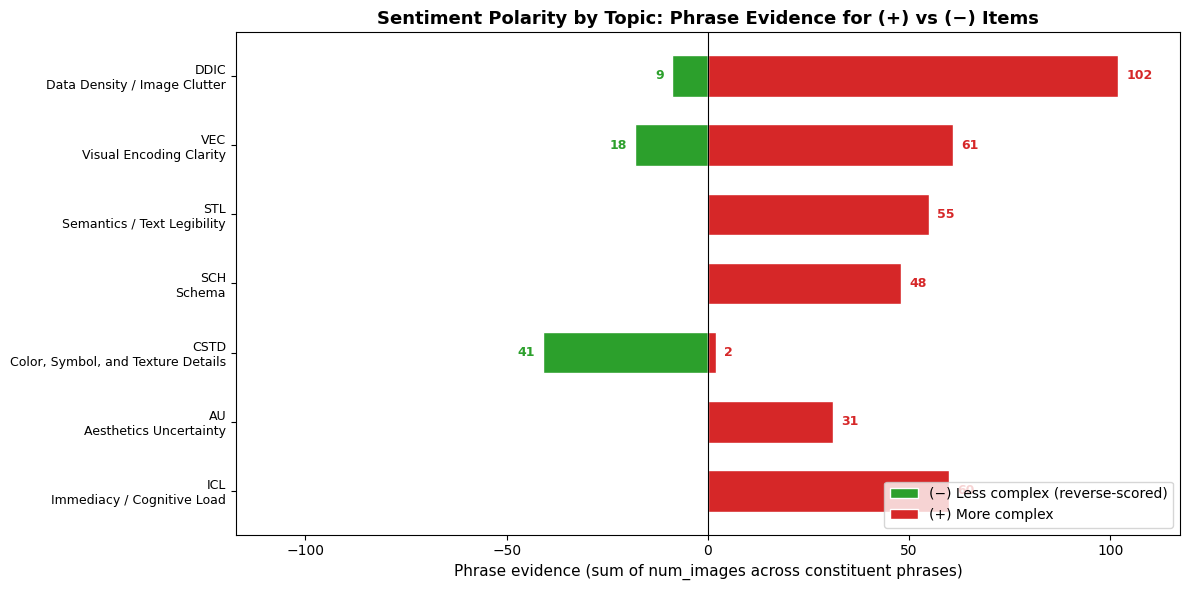


Topic                                             (+)     (−)    % (+)  Items (+/−)
-------------------------------------------------------------------------------------
Data Density / Image Clutter                      102       9      92%  2+ / 1−
Visual Encoding Clarity                            61      18      77%  2+ / 1−
Semantics / Text Legibility                        55       0     100%  3+ / 0−
Schema                                             48       0     100%  3+ / 0−
Color, Symbol, and Texture Details                  2      41       5%  1+ / 1−
Aesthetics Uncertainty                             31       0     100%  2+ / 0−
Immediacy / Cognitive Load                         60       0     100%  3+ / 0−
─────────────────────────────────────────────────────────────────────────────────────
TOTAL                                             359      68  84%


In [32]:
# ---- Sentiment polarity weighted by phrase evidence per topic ----
# For each subtopic in likert_df, expand its phrases and sum num_images from df_phrase_counts.
# Then aggregate by polarity (+/−) per topic.

topic_polarity_counts = {t: {'+': 0, '−': 0} for t in topic_names}

for _, item in likert_df.iterrows():
    topic = item['topic']
    polarity = item['polarity']
    phrases = [p.strip() for p in str(item['phrases']).split(';') if p.strip()]

    total_evidence = 0
    for phrase in phrases:
        match = df_phrase_counts[
            (df_phrase_counts['phrase'] == phrase) & (df_phrase_counts['topic'] == topic)
        ]
        if not match.empty:
            total_evidence += match['num_images'].sum()

    topic_polarity_counts[topic][polarity] += total_evidence

# ---- Diverging butterfly chart ----
fig, ax = plt.subplots(figsize=(12, 6))

pos_vals = [topic_polarity_counts[t]['+'] for t in topic_names]
neg_vals = [topic_polarity_counts[t]['−'] for t in topic_names]
y_pos = np.arange(len(topic_names))

# (−) on the left (negative x), (+) on the right (positive x)
bars_neg = ax.barh(y_pos, [-v for v in neg_vals], height=0.6,
                   color='#2ca02c', edgecolor='white', label='(−) Less complex (reverse-scored)')
bars_pos = ax.barh(y_pos, pos_vals, height=0.6,
                   color='#d62728', edgecolor='white', label='(+) More complex')

# Labels on bars
for i, (pv, nv) in enumerate(zip(pos_vals, neg_vals)):
    if pv > 0:
        ax.text(pv + 2, i, f'{int(pv)}', va='center', fontsize=9, color='#d62728', fontweight='bold')
    if nv > 0:
        ax.text(-nv - 2, i, f'{int(nv)}', va='center', fontsize=9, color='#2ca02c',
                fontweight='bold', ha='right')

ax.set_yticks(y_pos)
ax.set_yticklabels([f'{topic_abbrev[t]}\n{t}' for t in topic_names], fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Phrase evidence (sum of num_images across constituent phrases)', fontsize=11)
ax.set_title('Sentiment Polarity by Topic: Phrase Evidence for (+) vs (−) Items',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.invert_yaxis()

# Symmetric x-axis
all_vals = pos_vals + neg_vals
max_val = max(all_vals) * 1.15 if max(all_vals) > 0 else 1
ax.set_xlim(-max_val, max_val)

plt.tight_layout()
polarity_path = os.path.join(fig_dir, 'sentiment_diverging_by_topic.png')
fig.savefig(polarity_path, dpi=150, bbox_inches='tight')
print(f'Saved: {polarity_path}')
plt.show()

# ---- Print counts ----
print(f'\n{"Topic":<45s}  {"(+)":>6s}  {"(−)":>6s}  {"% (+)":>7s}  {"Items (+/−)"}')
print('-' * 85)
for t in topic_names:
    p = topic_polarity_counts[t]['+']
    n = topic_polarity_counts[t]['−']
    total = p + n
    pct = f'{p/total*100:.0f}%' if total > 0 else 'n/a'
    items_pos = len(likert_df[(likert_df['topic'] == t) & (likert_df['polarity'] == '+')])
    items_neg = len(likert_df[(likert_df['topic'] == t) & (likert_df['polarity'] == '−')])
    print(f'{t:<45s}  {int(p):>6d}  {int(n):>6d}  {pct:>7s}  {items_pos}+ / {items_neg}−')

total_pos = sum(topic_polarity_counts[t]['+'] for t in topic_names)
total_neg = sum(topic_polarity_counts[t]['−'] for t in topic_names)
total_all = total_pos + total_neg
print(f'{"─"*85}')
print(f'{"TOTAL":<45s}  {int(total_pos):>6d}  {int(total_neg):>6d}  '
      f'{total_pos/total_all*100:.0f}%' if total_all > 0 else '')